Ejemplo PID

In [1]:
# Import the packages needed for the examples included in this notebook
import numpy as np
import matplotlib.pyplot as plt
import control as ct

Definición del sistema

In [2]:
T = 0.1
num = [0.0070, 0.0066]
den = [1.0000, -1.8100, 0.8170]

sys = ct.tf(num, den, T)
print(sys)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

    0.007 z + 0.0066
  --------------------
  z^2 - 1.81 z + 0.817


Simulamos el sistema en BA

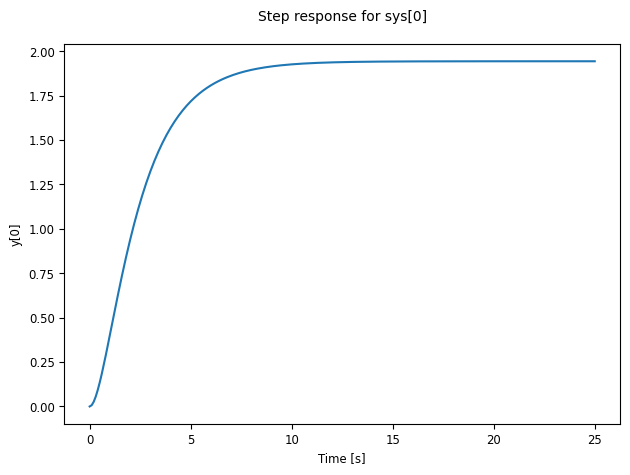

In [3]:
sal = ct.step_response(sys).plot()

Añadimos el controlador

In [4]:
num_cont = [18.8600, -31.8168, 13.0304]
den_cont = [1, -1, 0]

sys_cont = ct.tf(num_cont, den_cont, T)
print(sys_cont)

<TransferFunction>: sys[3]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

  18.86 z^2 - 31.82 z + 13.03
  ---------------------------
            z^2 - z


Obtenemos la realimentación

In [5]:
sys_serie = ct.series(sys, sys_cont)
print(sys_serie)
#sal_serie = ct.step_response(sys_serie).plot()
sal_loop_cont = ct.feedback(sys_serie, 1, sign = -1)
print(sal_loop_cont)

<TransferFunction>: sys[4]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

  0.132 z^3 - 0.09824 z^2 - 0.1188 z + 0.086
  ------------------------------------------
     z^4 - 2.81 z^3 + 2.627 z^2 - 0.817 z
<TransferFunction>: sys[6]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

    0.132 z^3 - 0.09824 z^2 - 0.1188 z + 0.086
  ----------------------------------------------
  z^4 - 2.678 z^3 + 2.529 z^2 - 0.9358 z + 0.086


Obtenemos la respuesta step

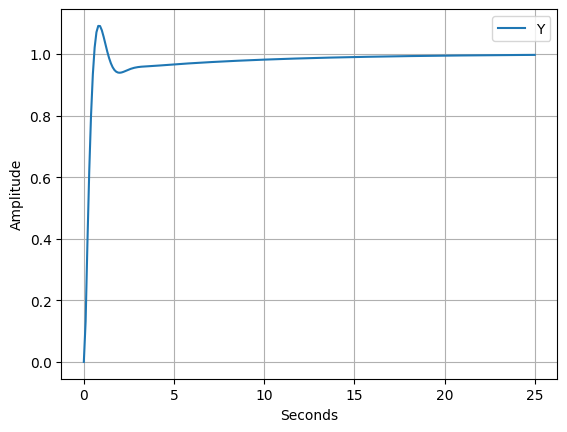

In [6]:
t, sal_loop = ct.step_response(sal_loop_cont)
plt.plot(t, sal_loop)
plt.grid()
plt.xlabel("Seconds")
plt.ylabel("Amplitude")
plt.legend("Y")